In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from scipy.sparse import hstack, csr_matrix
from sklearn.decomposition import TruncatedSVD
from scipy.sparse.linalg import lsqr

## Loading cleaned dataset

In [111]:
df = pd.read_csv('boston_housing_clean.csv')
df.head()

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_82801/3661573303.py:1: DtypeWarning: Columns (0: MAIL_ZIP_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('boston_housing_clean.csv')


,ST_NAME,CITY,ZIP_CODE,BLDG_SEQ,NUM_BLDGS,LUC,LU,LU_DESC,BLDG_TYPE,OWN_OCC,...,HEAT_TYPE,HEAT_SYSTEM,AC_TYPE,FIREPLACES,ORIENTATION,NUM_PARKING,PROP_VIEW,CORNER_UNIT,IS_RES,YEARS_SINCE_REMODEL
0,Lexington ST,EAST BOSTON,2128.0,1,1,105,R3,THREE-FAM DWELLING,RE - Row End,Y,...,W - Ht Water/Steam,NR - Not Required,N - None,0.0,NR - Not Required,3.0,A - Average,NR - Not Required,1,126.0
1,Lexington ST,EAST BOSTON,2128.0,1,1,105,R3,THREE-FAM DWELLING,RM - Row Middle,N,...,F - Forced Hot Air,NR - Not Required,C - Central AC,0.0,NR - Not Required,0.0,A - Average,NR - Not Required,1,26.0
2,Lexington ST,EAST BOSTON,2128.0,1,1,105,R3,THREE-FAM DWELLING,RM - Row Middle,N,...,S - Space Heat,NR - Not Required,N - None,0.0,NR - Not Required,0.0,A - Average,NR - Not Required,1,41.0
3,Lexington ST,EAST BOSTON,2128.0,1,1,105,R3,THREE-FAM DWELLING,RM - Row Middle,N,...,W - Ht Water/Steam,NR - Not Required,N - None,0.0,NR - Not Required,0.0,A - Average,NR - Not Required,1,35.0
4,Lexington ST,EAST BOSTON,2128.0,1,1,105,R3,THREE-FAM DWELLING,RE - Row End,N,...,W - Ht Water/Steam,NR - Not Required,N - None,0.0,NR - Not Required,0.0,A - Average,NR - Not Required,1,48.0


In [112]:
df.shape

(167731, 50)

## Feature Evaluation

In [113]:
for col in df.columns:
    print(f"{col:30s}  dtype: {df[col].dtype}  unique: {df[col].nunique()}")

ST_NAME                         dtype: str  unique: 4464
CITY                            dtype: str  unique: 19
ZIP_CODE                        dtype: float64  unique: 38
BLDG_SEQ                        dtype: int64  unique: 1
NUM_BLDGS                       dtype: int64  unique: 1
LUC                             dtype: int64  unique: 195
LU                              dtype: str  unique: 16
LU_DESC                         dtype: str  unique: 188
BLDG_TYPE                       dtype: str  unique: 203
OWN_OCC                         dtype: str  unique: 2
MAIL_CITY                       dtype: str  unique: 2241
MAIL_STATE                      dtype: str  unique: 75
MAIL_ZIP_CODE                   dtype: object  unique: 4036
RES_FLOOR                       dtype: float64  unique: 30
CD_FLOOR                        dtype: float64  unique: 62
LAND_SF                         dtype: float64  unique: 16278
GROSS_AREA                      dtype: float64  unique: 13044
LIVING_AREA             

In [114]:
print(df.columns.tolist())

['ST_NAME', 'CITY', 'ZIP_CODE', 'BLDG_SEQ', 'NUM_BLDGS', 'LUC', 'LU', 'LU_DESC', 'BLDG_TYPE', 'OWN_OCC', 'MAIL_CITY', 'MAIL_STATE', 'MAIL_ZIP_CODE', 'RES_FLOOR', 'CD_FLOOR', 'LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'LAND_VALUE', 'BLDG_VALUE', 'SFYI_VALUE', 'TOTAL_VALUE', 'GROSS_TAX', 'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED', 'INT_COND', 'EXT_COND', 'OVERALL_COND', 'BED_RMS', 'TT_RMS', 'BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE', 'FIREPLACES', 'ORIENTATION', 'NUM_PARKING', 'PROP_VIEW', 'CORNER_UNIT', 'IS_RES', 'YEARS_SINCE_REMODEL']


In [115]:
def projection_from_onehot(X, y):
    """
    Compute projection of y onto span(X) where X is one-hot encoded.

    Args:
        X (np.ndarray): one-hot matrix (n_samples, n_categories)
        y (np.ndarray): target vector (n_samples,)

    Returns:
        y_hat (np.ndarray): projection vector
        coeff (np.ndarray): per-category coefficients (means)
        residual (np.ndarray): y - y_hat
    """

    # counts per category
    count = X.sum(axis=0)

    # avoid division by zero
    count = np.where(count == 0, 1, count)

    # projection coefficients (means)
    coeff = (X.T @ y) / count

    # projection vector
    y_hat = X @ coeff

    # residual
    residual = y - y_hat

    return y_hat, coeff, residual

### LOCATION FEATURES (ST_NAME, CITY, and ZIP_CODE)

It has ~4.4k unique values, since its categorical feature we need to one-hot encode this, 4.4l features => 4.4k dimensional vector after one-hot encoding, but before dropping lets do a correlation analysis to understand if this 4.4k sized vector can help us significantly explain the target feature vector

In [116]:
X_st = pd.get_dummies(df["ST_NAME"]).astype(int)
y = np.log1p(df["TOTAL_VALUE"])
print(X_st)
print("\n", y)

        A ST  ABBOT ST  ABBOTSFORD ST  ABBY RD  ACACIA RD  ACADIA ST  \
0          0         0              0        0          0          0   
1          0         0              0        0          0          0   
2          0         0              0        0          0          0   
3          0         0              0        0          0          0   
4          0         0              0        0          0          0   
...      ...       ...            ...      ...        ...        ...   
167726     0         0              0        0          0          0   
167727     0         0              0        0          0          0   
167728     0         0              0        0          0          0   
167729     0         0              0        0          0          0   
167730     0         0              0        0          0          0   

        ACHORN CI  ACKLEY PL  ACTON ST  ADA ST  ...  YARMOUTH ST  YORK ST  \
0               0          0         0       0  ...       

#### Finding R2 score between projection vector of target on a feature column and target vector tells us how much better is the feature vector compared to just predicting the mean value of the target vector -

1. R2 < 0 -> Better to use mean
2. R2 = 0 -> Same as mean
3. R2 > 0 -> Better than mean

In [117]:
# Projection - We are projecting the target vector 'y' onto the space
# spanned by the feature X (ST_NAME). This will give us the closest
# vector to 'y' that lies inside the feature span. This vector tells
# us "how much" of the target can be explained by the feature. The residual
# or difference between y_true (target column) and project vector (y_hat)
# or projection of target on feature column vector tells us "how much"
# of target cannot be explained by the feature

# Projection = y_hat​=X(XᵀX)⁻¹Xᵀy
# Projection coeff = (XᵀX)⁻¹Xᵀy

# Since we have one-hot encoded matrix, the diagonal values of XᵀX
# will give us the count of houses on the street, since no house
# can belong to 2 streets. For (XᵀX)⁻¹ the diagonal entries would
# give us 1/count(j) at col j, or 1/number of houses for that street

# (XᵀX)⁻¹ = diag(1/count)

# Xᵀy just gives us -
# Street A column: x_j = [0, 1, 0, 1]
# y (prices):      [100, 200, 300, 400]
# 200+400 = 600
# so it gives us sum of target values of houses on that street = xjᵀy

# Projection coefficient = (XᵀX)⁻¹Xᵀy = diag(1/count) . xjᵀy = xjᵀy/count(j)
res = projection_from_onehot(X_st, y)

print("How much ST_NAME does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much ST_NAME does NOT explain log transformed target values:  415.7616701396036
Explained variance (R²): 0.258207926293314


It explains 25% of variance, so it has some predictive power. However with its high dimensionality its still not strong enough to keep it, we need to either extract information from it or drop it altogether. Lets explore CITY and ZIP_CODE (location features) first before deciding what to do with ST_NAME

In [118]:
# Projection = y_hat​=X(XᵀX)⁻¹Xᵀy
X_city = pd.get_dummies(df["CITY"]).astype(int)

res = projection_from_onehot(X_city, y)

print("How much CITY does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))


How much CITY does NOT explain log transformed target values:  473.98583790461566
Explained variance (R²): 0.03589569297386941


CITY is a weaker feature than ST_NAME

In [119]:
# Projection = y_hat​=X(XᵀX)⁻¹Xᵀy
X_zip = pd.get_dummies(df["ZIP_CODE"]).astype(int)

res = projection_from_onehot(X_zip, y)

print("How much ZIP_CODE does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))


How much ZIP_CODE does NOT explain log transformed target values:  468.6282398328809
Explained variance (R²): 0.057567610675675285


ZIP_CODE is a stronger feature than city but weaker compared to ST_NAME. This makes sense, as the street a house belongs to would have more predictive power because precision locations are more powerful indicators of property values, some streets are just more valuable, so all properties in that street have higher value

Now we have a dimensionality problem for location where strong features like ST_NAME have very fine granuality (high dimensionality) but strong predictive power, and weak features have low dimensionality but also weak predictive power

We can try to come up with a combined feature - each feature spans a subspace, we can analyze all 3 subspaces of our location features to see overlap between them

In [120]:
X_combined = np.concatenate([X_st, X_city, X_zip], axis=1)
print(X_combined.shape)

(167731, 4521)


Combined matrix is too high dimensional to use standard formula for finding projection vector of y onto X_combined, which would require pseudo-inverse. But we can use sparsity (most entries are 0 in one-hot encoded combined matrix) where we use only non-zero entries to find the approximate projection vector of y on X_combined. We will use iterative solver (LSQR) for this, instead of directly computing the projection vector (which in this case is computationally infeasible), iterative solvers start with a guess and then improve step by step. We do not get the true projection but a very close approximate of it

In [121]:
# one-hot encode and convert to sparse
X_st = pd.get_dummies(df["ST_NAME"], sparse=True)
X_zip = pd.get_dummies(df["ZIP_CODE"], sparse=True)
X_city = pd.get_dummies(df["CITY"], sparse=True)

X_st_sparse = X_st.sparse.to_coo().tocsr()
X_zip_sparse = X_zip.sparse.to_coo().tocsr()
X_city_sparse = X_city.sparse.to_coo().tocsr()

# combine location features
X_combined = hstack([X_st_sparse, X_zip_sparse, X_city_sparse], format="csr")

# LSQR solve
result = lsqr(X_combined, y)

w = result[0]                 # coefficients
y_hat = X_combined @ w        # projection / fitted values
r2_full = r2_score(y, y_hat)

print("Combined R²:", r2_full)
print("Residual norm:", np.linalg.norm(y - y_hat))
print("LSQR iterations:", result[2])
print("LSQR stop code:", result[1])

Combined R²: 0.267964138658776
Residual norm: 413.01852625262114
LSQR iterations: 547
LSQR stop code: 2


It is clear that CITY and ZIP_CODE do not add much value, ST_NAME alone explained 25.8% of variance, the combined feature space of ST_NAME, CITY, and ZIP_CODE explains 26.8% of variance in target feature, just a 1% jump. This still doesn't solve the problem because even if we drop CITY and ZIP_CODE we are only left with ST_NAME as a location feature which is very high dimensional (4.4k)

In [122]:
dims = [1, 2, 5, 10, 20, 50, 100]
results = []

for k in dims:
    svd = TruncatedSVD(n_components=k, random_state=42)
    Z = svd.fit_transform(X_combined)   # dense n x k matrix

    # project y onto reduced space
    w_k = lsqr(Z, y)[0]
    y_hat_k = Z @ w_k
    r2_k = r2_score(y, y_hat_k)

    preserved = r2_k / r2_full if r2_full > 0 else np.nan
    results.append((k, r2_k, preserved, svd.explained_variance_ratio_.sum()))

for row in results:
    print(f"k={row[0]:3d} | R²={row[1]:.6f} | preserved={row[2]:.3%} | X-var kept={row[3]:.3%}")

k=  1 | R²=-92.819859 | preserved=-34638.911% | X-var kept=7.774%
k=  2 | R²=-72.736606 | preserved=-27144.157% | X-var kept=13.963%
k=  5 | R²=-38.119621 | preserved=-14225.643% | X-var kept=27.761%
k= 10 | R²=-12.973707 | preserved=-4841.583% | X-var kept=45.833%
k= 20 | R²=-2.318329 | preserved=-865.164% | X-var kept=61.384%
k= 50 | R²=0.025754 | preserved=9.611% | X-var kept=70.910%
k=100 | R²=0.043668 | preserved=16.296% | X-var kept=74.981%


TruncatedSVD preserves variance in the feature matrix, but fails to preserve predictive signal because the location effect is highly localized and not aligned with the principal components. Therefore, no low-dimensional linear projection of the combined location features captures the original explanatory power

In [123]:
# how many ZIP codes per street
st_zip_counts = df.groupby("ST_NAME")["ZIP_CODE"].nunique()

# streets that appear in multiple ZIPs
multi_zip_streets = st_zip_counts[st_zip_counts > 1]

print("Total unique streets:", len(st_zip_counts))
print("Streets with multiple ZIP codes:", len(multi_zip_streets))

Total unique streets: 4464
Streets with multiple ZIP codes: 430


This gives us an important information - some streets belong to more than one ZIP_CODE (not physically ofcourse), but 2 ZIP_CODE areas can both have a street named Washington St. This adds ambiguity for just the ST_NAME alone. Hence, (ST_NAME + ZIP_CODE) might be a stronger feature than just ST_NAME alone. Lets test this

In [124]:
df["ST_ZIP"] = df["ST_NAME"].astype(str) + "_" + df["ZIP_CODE"].astype(str)

In [125]:
X_stzip = pd.get_dummies(df["ST_ZIP"], sparse=True).sparse.to_coo().tocsr()

from scipy.sparse.linalg import lsqr
from sklearn.metrics import r2_score

w = lsqr(X_stzip, y)[0]
y_hat = X_stzip @ w

print("R² ST_NAME + ZIP combined:", r2_score(y, y_hat))

R² ST_NAME + ZIP combined: 0.301350233067474


Hypothesis was correct - ST_NAME + ZIP_CODE explains 30% variance in y, ~4% jump from ST_NAME alone

However, the high cardinality problem still remains, infact by removing duplicate ST_NAME we have definitely increased our cardinality

In [126]:
X_stzip.shape

(167731, 5088)

Even though X_stzip is a stronger feature than ST_NAME, it has even more dimensionality than ST_NAME

We are stuck at a real bottleneck, one option is to leave the categories as they are even though we have 5088 unique categories, modern boosting algorithms have native categorical feature handling, often they perform better on high unique category features than using methods to transform the feature like target encoding which has a high data leakage risk. For now lets just leave the X_stzip feature as is and drop ZIP_CODE, and ST_NAME. Lets keep city as it might contain some standalone information

In [127]:
print(df['ST_ZIP'])

0            Lexington ST_2128.0
1            Lexington ST_2128.0
2            Lexington ST_2128.0
3            Lexington ST_2128.0
4            Lexington ST_2128.0
                   ...          
167726         KNOWLES ST_2135.0
167727            Lake ST_2135.0
167728            Lake ST_2135.0
167729    COMMONWEALTH AV_2135.0
167730    COMMONWEALTH AV_2135.0
Name: ST_ZIP, Length: 167731, dtype: str


ZIP_CODES are float, converting them to str

In [128]:
df["ZIP_CODE"] = df["ZIP_CODE"].astype(int).astype(str)
df["ST_ZIP"] = df["ST_NAME"].astype(str) + "_" + df["ZIP_CODE"]
print(df["ST_ZIP"])

0            Lexington ST_2128
1            Lexington ST_2128
2            Lexington ST_2128
3            Lexington ST_2128
4            Lexington ST_2128
                  ...         
167726         KNOWLES ST_2135
167727            Lake ST_2135
167728            Lake ST_2135
167729    COMMONWEALTH AV_2135
167730    COMMONWEALTH AV_2135
Name: ST_ZIP, Length: 167731, dtype: str


In [129]:
df = df.drop(columns=['ZIP_CODE', 'ST_NAME'])

### Not important features that were missed in cleaning (only 1 unique value)

In [130]:
print(df['BLDG_SEQ'].unique())

[1]


In [131]:
print(df['NUM_BLDGS'].unique())

[1]


In [132]:
df = df.drop(columns=['NUM_BLDGS', 'BLDG_SEQ'])

### Property owner features (MAIL_CITY, MAIL_STATE, MAIL_ZIP_CODE, and OWN_OCC)

In [133]:
own = ['MAIL_CITY', 'MAIL_STATE', 'MAIL_ZIP_CODE', 'OWN_OCC']
for i in own:
    print("\n"f'{i}: ', df[i].unique())


MAIL_CITY:  <StringArray>
[    'EAST BOSTON',       'WAKEFIELD',         'EVERETT',          'NEWTON',
          'OAKTON',        'E BOSTON',         'PEABODY',       'BROOKLINE',
          'REVERE',          'BOSTON',
 ...
   'SOUTH WALPOLE',        'HARTVARD',       'BROOKIINE',       'WOODHAVEN',
     'COLLEYVILLE',         'GARDNER', 'EAST  GREENWICH',        'CLARENCE',
       'ANNAPOLIS',       'SEA CLIFF']
Length: 2241, dtype: str

MAIL_STATE:  <StringArray>
[                    'MA',                     'VA',                     'NH',
                     'CA',                     'AR',                     'NJ',
                     'WA',                     'PA',                     'NY',
                     'TX',                     'FL',                     'RI',
                     'ME',                     'NV',                     'MO',
                     'OH',                     'CT',                     'IL',
                     'MD',                     'OK',   

In [134]:
X_mail = pd.get_dummies(df["MAIL_CITY"]).astype(int)

res = projection_from_onehot(X_mail, y)

print("How much MAIL_CITY does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))


How much MAIL_CITY does NOT explain log transformed target values:  470.03689623809134
Explained variance (R²): 0.05189335300302411


MAIL_CITY explains 5% variance in the target feature -> weak feature

In [135]:
X_mail_state = pd.get_dummies(df["MAIL_STATE"]).astype(int)

res = projection_from_onehot(X_mail_state, y)

print("How much MAIL_STATE does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much MAIL_STATE does NOT explain log transformed target values:  481.96094931676015
Explained variance (R²): 0.0031794241218049413


MAIL_STATE explains 0.3% variance in target feature -> almost no learning signal -> definitely drop

In [136]:
X_mail_zip = pd.get_dummies(df["MAIL_ZIP_CODE"]).astype(int)

res = projection_from_onehot(X_mail_zip, y)

print("How much MAIL_ZIP_CODE does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much MAIL_ZIP_CODE does NOT explain log transformed target values:  456.9559157985476
Explained variance (R²): 0.10393007783874231


MAIL_ZIP_CODE explains 10% variance in target feature -> strongest mail feature but still not strong enough. We can drop this or try feature engineering it

Lets see if MAIL_ZIP_CODE + MAIL_CITY would account for better variance explanation than MAIL_ZIP_CODE alone

In [137]:
X_combined = np.concatenate([X_mail_zip, X_mail], axis=1)
print(X_combined.shape)

X_mail_zip = pd.get_dummies(df["MAIL_ZIP_CODE"], sparse=True)
X_mail = pd.get_dummies(df["MAIL_CITY"], sparse=True)

X_mail_zip_sparse = X_mail_zip.sparse.to_coo().tocsr()
X_mail_sparse = X_mail.sparse.to_coo().tocsr()

X_combined = hstack([X_mail_zip_sparse, X_mail_sparse], format="csr")

# LSQR solve
result = lsqr(X_combined, y)

w = result[0]                 # coefficients
y_hat = X_combined @ w        # projection / fitted values
r2_full = r2_score(y, y_hat)

print("Combined R²:", r2_full)
print("Residual norm:", np.linalg.norm(y - y_hat))
print("LSQR iterations:", result[2])
print("LSQR stop code:", result[1])

(167731, 6277)
Combined R²: 0.10857111130892094
Residual norm: 455.77101895649844
LSQR iterations: 911
LSQR stop code: 2


0.005 gain in R2 score, negligible but MAIL_CITY still does carry some signal

In [138]:
df['OWN_OCC'].unique

<bound method Series.unique of 0         Y
1         N
2         N
3         N
4         N
         ..
167726    N
167727    N
167728    N
167729    N
167730    N
Name: OWN_OCC, Length: 167731, dtype: str>

In [139]:
X_own = pd.get_dummies(df['OWN_OCC'], dtype=float).values

proj_coeff = np.linalg.inv(X_own.T @ X_own) @ X_own.T @ y
proj_vec = X_own @ proj_coeff

print("How much MAIL_ZIP_CODE does NOT explain log transformed target values: ", np.linalg.norm(y - proj_vec))
print("Explained variance (R²):", r2_score(y, proj_vec))

How much MAIL_ZIP_CODE does NOT explain log transformed target values:  476.760400779611
Explained variance (R²): 0.02457553523557854


OWN_OCC explains 2% variance in target feature -> very weak feature

In [140]:
df = df.drop(columns = ['MAIL_STATE', 'OWN_OCC'])

## Land use features (LUC, LU, and LU_DESC)

In [141]:
own = ['LUC', 'LU', 'LU_DESC']
for i in own:
    print("\n"f'{i}: ', df[i].unique())


LUC:  [105 102 104 101 109 120 125 111 327  13 112 333  31 320 325 343 132 985
 332 106 337 402 316 319 326 342 465 902 901 986 387 312 420 446 335 328
 315 317 300 968 130 904 341 353 976 970 351 945 401 908 903 311 395 314
 390 391 906 304 907 108 356 357 336 905 121 975 414 973 129 978 334 437
 307 384 404 969 941 407 954 962 340 358 974 118 369 306 991 350 119 953
 406 329 344 439 324 370 131 127 980 979 958 346 424 400 444 957 405 352
 952 318 977 947 403 966 960 992 900 950 113 924 345 965 440 441 122 376
 126 971 116 961 347 338 117 450 339 374 330 361 301 388 365 972 355 436
 987 348 942 951 946 990 364 362 322 123 303 937 124 375 955 422 438 302
 359 929 392 393 963 331 321 415 310 433 379 377 114 959 413 378 399 435
 988 309 914 925 427 982 412 305 983 981 717 417 410 442 943]

LU:  <StringArray>
[     'R3',      'CD',      'R2',      'R1',       'A',      'R4',       'C',
      'RC', 'RL - RL',       'E',      'CL',       'I',      'EA',      'CP',
      'CC',      'AH']
Le

In [142]:
X_lu = pd.get_dummies(df['LU'], dtype=float).values

proj_coeff = np.linalg.inv(X_lu.T @ X_lu) @ X_lu.T @ y
proj_vec = X_lu @ proj_coeff

print("How much LU does NOT explain log transformed target values: ", np.linalg.norm(y - proj_vec))
print("Explained variance (R²):", r2_score(y, proj_vec))

How much LU does NOT explain log transformed target values:  349.8923918920382
Explained variance (R²): 0.47463360459102466


LU explains 47% variance in the target feature -> very strong feature

In [143]:
X_lu_desc = pd.get_dummies(df['LU_DESC'], dtype=float).values

res = projection_from_onehot(X_lu_desc, y)

print("How much LU_DESC does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much LU_DESC does NOT explain log transformed target values:  310.87265759724556
Explained variance (R²): 0.585276787992828


LU_DESC explains 58% variance in the target feature -> very strong feature

In [144]:
X_luc = pd.get_dummies(df['LUC'], dtype=float).values

res = projection_from_onehot(X_luc, y)

print("How much LUC does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much LUC does NOT explain log transformed target values:  310.7651431866822
Explained variance (R²): 0.585563600037285


LUC has almost the same score as LU_DESC which makes sense, as it is the code for Land use description (they are the same feature) -> LU_DESC is the description of the land use, and LUC is the unique code given to that land use description, since LUC is slightly higher score lets keep that

In [145]:
print(df.groupby('LU')['LUC'].nunique().sort_values(ascending=False))
print("\n", df[['LU', 'LUC', 'LU_DESC']].drop_duplicates().sort_values(['LU', 'LUC']).to_string())

LU
C          70
E          57
I          23
A          16
CL          9
CC          5
RL - RL     4
R3          2
RC          2
AH          1
CD          1
CP          1
EA          1
R1          1
R2          1
R4          1
Name: LUC, dtype: int64

              LU  LUC                       LU_DESC
79            A  112                APT 7-30 UNITS
14706         A  113               APT 31-99 UNITS
77861         A  114                APT 100+ UNITS
16774         A  116            RES PARKING GARAGE
18502         A  117               DAY CARE CENTER
7242          A  118                  ELDERLY HOME
7854          A  119               RES PARKING LOT
48            A  120              LUXURY APARTMENT
4142          A  121                 ROOMING HOUSE
16119         A  122                LODGING SUITES
34995         A  123          DORM /Residence Hall
35827         A  124                 DORMITORY  bd
59            A  125            SUBSD HOUSING S- 8
16596         A  126          SUB

LUC is a numeric sub-code for Land Use, lets see if combining LU and LUC would give us a higher predictive signal than just LUC, before we check the combined score which is computationally more expensive, lets just just the collinearity between LU and LUC, if they are perfectly collinear then we can drop LU. Since they are categorical features we will use Cramer_v test for finding dependence

In [146]:
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, c = contingency.shape

    return np.sqrt(chi2 / (n * (min(r-1, c-1))))

In [147]:
cramers_v(df["LU"], df["LUC"])

np.float64(1.0)

Cramér’s V = 1.0 indicates perfect association between LU and LUC. However, this does not imply that both features carry the same information. In this case, LUC is a finer-grained version of LU, resulting in a many-to-one mapping (LUC → LU). Because LUC preserves more detailed category information, it explains more variance in the target. Therefore, LU is redundant and can be safely dropped

In [148]:
X_lu = pd.get_dummies(df["LU"], sparse=True)
X_luc = pd.get_dummies(df["LUC"], sparse=True)

X_lu_sparse = X_lu.sparse.to_coo().tocsr()
X_luc_sparse = X_luc.sparse.to_coo().tocsr()

# combine location features
X_combined = hstack([X_lu_sparse, X_luc_sparse], format="csr")

# LSQR solve
result = lsqr(X_combined, y.values)

w = result[0]                 # coefficients
y_hat = X_combined @ w        # projection / fitted values
r2_full = r2_score(y, y_hat)

print("Combined R²:", r2_full)
print("Residual norm:", np.linalg.norm(y - y_hat))
print("LSQR iterations:", result[2])
print("LSQR stop code:", result[1])

Combined R²: 0.5855635526952336
Residual norm: 310.7651609364007
LSQR iterations: 180
LSQR stop code: 2


Lets check correlation between LU_DESC and LUC to see if LU_DESC carries any information that LUC doesn't

In [149]:
contingency = pd.crosstab(df['LU_DESC'], df['LUC'])
chi2, p, dof, _ = chi2_contingency(contingency)

n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramér's V (LU_DESC vs LUC): {cramers_v:.4f}")
print("1.0 = perfect association, 0 = no association")

Cramér's V (LU_DESC vs LUC): 1.0000
1.0 = perfect association, 0 = no association


Perfect association, lets keep LUC since its more fine grained

In [150]:
contingency = pd.crosstab(df['LU'], df['LUC'])
chi2, p, dof, _ = chi2_contingency(contingency)

n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramér's V (LU vs LUC): {cramers_v:.4f}")
print("1.0 = perfect association, 0 = no association")

Cramér's V (LU vs LUC): 1.0000
1.0 = perfect association, 0 = no association


Perfect association here as well, makes sense to drop LU, LU_DESC

Lets check if LU combined with LUC gives gains in r2_score

In [151]:
X_lu = pd.get_dummies(df["LU"], sparse=True)
X_luc = pd.get_dummies(df["LUC"], sparse=True)

X_lu_sparse = X_lu.sparse.to_coo().tocsr()
X_luc_sparse = X_luc.sparse.to_coo().tocsr()

# combine location features
X_combined = hstack([X_lu_sparse, X_luc_sparse], format="csr")

# LSQR solve
result = lsqr(X_combined, y.values)

w = result[0]                 # coefficients
y_hat = X_combined @ w        # projection / fitted values
r2_full = r2_score(y, y_hat)

print("Combined R²:", r2_full)
print("Residual norm:", np.linalg.norm(y - y_hat))
print("LSQR iterations:", result[2])
print("LSQR stop code:", result[1])

Combined R²: 0.5855635526952336
Residual norm: 310.7651609364007
LSQR iterations: 180
LSQR stop code: 2


In [152]:
df = df.drop(columns = ['LU', 'LU_DESC'])

## Floor features (RES_FLOOR and CD_FLOOR)

In [153]:
floors = ['CD_FLOOR', 'RES_FLOOR']
for i in floors:
    print("\n"f'{i}: ', df[i].unique())


CD_FLOOR:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 13. 36. 37. 38. 39. 40. 41. 42. 43. 45. 46. 47.
 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62.]

RES_FLOOR:  [ 3.   1.   2.   1.5  2.5 -1.   4.   3.5  5.   7.   4.5  6.  16.  11.
 10.  46.   5.5 14.  19.  30.   8.   0.  20.   9.  29.  12.  13.  21.
 24.   2.4]


We should treat CD_FLOOR as numerical (clear numerical values - floor 11 > floor 10), but RES_FLOOR as categorical (-1 value indicates missing datapoint, floating values like 1.5)

In [154]:
# add intercept
X = df['CD_FLOOR'].values.reshape(-1, 1)
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

# projection
coeff = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
y_hat = X_aug @ coeff

print("Residual norm:", np.linalg.norm(y - y_hat))
print("R²:", r2_score(y, y_hat))

Residual norm: 477.43241103626735
R²: 0.0218238083075879


CD_FLOOR information feature, its better to predict the mean of target vector

In [155]:
X_floor = pd.get_dummies(df['RES_FLOOR'], dtype=float).values

res = projection_from_onehot(X_floor, y)

print("How much RES_FLOOR does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much RES_FLOOR does NOT explain log transformed target values:  429.22963573721586
Explained variance (R²): 0.2093710890536784


RES_FLOOR explains 20% variance in target feature -> keep

In [156]:
df = df.drop(columns = ['CD_FLOOR'])

## Area features (LAND_SF, GROSS_AREA, and LIVING_AREA)

In [157]:
area = ['LAND_SF', 'GROSS_AREA', 'LIVING_AREA']
for i in area:
    print("\n"f'{i}: ', df[i].unique())


LAND_SF:  [ 1150.  2010.  2500. ... 10838.  7823. 34125.]

GROSS_AREA:  [ 3353.  3047.  3392. ... 11345. 10593. 14520.]

LIVING_AREA:  [2202.  2307.  2268.  ... 6253.  5769.6 7386. ]


In [158]:
# add intercept
X = df['LAND_SF'].values.reshape(-1, 1)
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

# projection
coeff = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
y_hat = X_aug @ coeff

print("Residual norm:", np.linalg.norm(y - y_hat))
print("R²:", r2_score(y, y_hat))

Residual norm: 481.84218530858175
R²: 0.0036706332992453294


In [159]:
# add intercept
X = df['GROSS_AREA'].values.reshape(-1, 1)
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

# projection
coeff = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
y_hat = X_aug @ coeff

print("Residual norm:", np.linalg.norm(y - y_hat))
print("R²:", r2_score(y, y_hat))

Residual norm: 466.1582857374996
R²: 0.06747580731717195


In [160]:
# add intercept
X = df['LIVING_AREA'].values.reshape(-1, 1)
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

# projection
coeff = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
y_hat = X_aug @ coeff

print("Residual norm:", np.linalg.norm(y - y_hat))
print("R²:", r2_score(y, y_hat))

Residual norm: 467.59108546784006
R²: 0.0617345223288176


#### All area features by themselves have low predictive power, but area is a important feature for valuation of any property, dropping it does not make sense. “we retained features that are theoretically relevant and may contribute conditional signal, even if their standalone explanatory power is low. Just because a feature is a weak predictor in isloation doesn't mean it will not add any value when combined with other rich features

In [161]:
import numpy as np
from sklearn.metrics import r2_score

area_cols = ["GROSS_AREA", "LIVING_AREA", "LAND_SF"]

X = df[area_cols].values
y = np.log1p(df["TOTAL_VALUE"].values)

# add intercept
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

In [162]:
coeff = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
y_hat = X_aug @ coeff

print("Residual norm:", np.linalg.norm(y - y_hat))
print("R² (combined area):", r2_score(y, y_hat))

Residual norm: 463.9963745803746
R² (combined area): 0.07610532058465136


Combined area is just ~1% increase, that is something to look at. One reason could be using -1 to fill NaN values in area features, it might not be acting as a signal of missing value but something like "negative area". Lets test by replacing all -1 with 0

In [163]:
import numpy as np
from sklearn.metrics import r2_score

area_cols = ["GROSS_AREA", "LIVING_AREA", "LAND_SF"]
y = np.log1p(df["TOTAL_VALUE"].values)

# replace sentinel -1 with 0
X_raw = df[area_cols].replace(-1, 0).values.astype(float)
X_aug_raw = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

coeff_raw = np.linalg.pinv(X_aug_raw) @ y
y_hat_raw = X_aug_raw @ coeff_raw

print("Residual norm (combined area, raw):", np.linalg.norm(y - y_hat_raw))
print("R² (combined area, raw):", r2_score(y, y_hat_raw))

Residual norm (combined area, raw): 463.9964580321329
R² (combined area, raw): 0.07610498825169953


Almost the same result as with -1, so replacing -1 with 0 did not help

Another reason could be that we are calculating predictive power of area on log-scaled value. Maybe it is better to use log of area to predict log of value. Lets test this

In [164]:
# Using log area feature
X_log = np.log1p(X_raw)
X_aug_log = np.hstack([np.ones((X_log.shape[0], 1)), X_log])

coeff_log = np.linalg.pinv(X_aug_log) @ y
y_hat_log = X_aug_log @ coeff_log

print("Residual norm (combined area, log):", np.linalg.norm(y - y_hat_log))
print("R² (combined area, log):", r2_score(y, y_hat_log))

Residual norm (combined area, log): 302.4911532343299
R² (combined area, log): 0.6073382055990635


The log transformed area combined feature explains ~60% variance in target feature. This is the strongest predictor so far, which makes sense, as area is probably the most indictive of the valuation of a property. Lets keep all 3 area features

## Psuedo-target features (LAND_VALUE, BLDG_VALUE, SFYI_VALUE, and GROSS_TAX)

In [165]:
import numpy as np

cols = ["LAND_VALUE", "BLDG_VALUE", "SFYI_VALUE"]

X = df[cols].values.astype(float)

In [166]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [167]:
rank = np.linalg.matrix_rank(X)
print("Rank:", rank)
print("Num cols:", X.shape[1])

Rank: 3
Num cols: 3


If rank would be < number of columns then we would have perfect collinearity. We may not have perfect but very high collinearity

In [168]:
# All these features are collinear with out target feature, using them as predictors is data leakage
cols = ["LAND_VALUE", "BLDG_VALUE", "SFYI_VALUE"]

y = df["TOTAL_VALUE"].values

# Pearson correlation
for col in cols:
    X = df[col].values
    
    cov = np.cov(X, y)[0, 1] # np.cov returns matrix, we need
    std_x = np.std(X)
    std_y = np.std(y)
    
    rho = cov / (std_x * std_y)
    
    print(f"Correlation with {col}: {rho}")

Correlation with LAND_VALUE: 0.8085848816372712
Correlation with BLDG_VALUE: 0.9690048851511716
Correlation with SFYI_VALUE: 0.07906678176082846


All 3 of value features have > ~0.80 correlation with TOTAL_VALUE, which indicates probable collinearity

In [169]:
# Lets try a regression based test

X = df[["BLDG_VALUE", "SFYI_VALUE", "LAND_VALUE"]].values
y_land = df["TOTAL_VALUE"].values

X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
coeff = np.linalg.pinv(X_aug) @ y_land
y_hat = X_aug @ coeff

print("R² (value from others):", r2_score(y_land, y_hat))

R² (value from others): 1.0


R2 of 1 indicates strong collinearity, TOTAL_VALUE is perfectly explained by ["BLDG_VALUE", "SFYI_VALUE", "LAND_VALUE"] -> Data leakage, we need to drop these columns

Lets check GROSS_TAX

In [170]:
# Convert GROSS_TAX to float
df['GROSS_TAX'] = pd.to_numeric(
    df['GROSS_TAX'].str.replace(r'[\$,\s]', '', regex=True),
    errors='coerce'
)
df['GROSS_TAX'] = df['GROSS_TAX'].fillna(0)

In [171]:
X = df[["GROSS_TAX"]].values.astype(float)
y_land = df["TOTAL_VALUE"].values.astype(float)

print("NaN in X:", np.isnan(X).any())
print("Inf in X:", np.isinf(X).any())
print("NaN in y:", np.isnan(y_land).any())
print("Inf in y:", np.isinf(y_land).any())

print("Min/Max X:", np.nanmin(X), np.nanmax(X))
print("Min/Max y:", np.nanmin(y_land), np.nanmax(y_land))

NaN in X: False
Inf in X: False
NaN in y: False
Inf in y: False
Min/Max X: 0.0 22869674.63
Min/Max y: 100.0 2448193300.0


In [172]:
X = df[["GROSS_TAX"]].values
y_land = df["TOTAL_VALUE"].values

X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
coeff = np.linalg.pinv(X_aug) @ y_land
y_hat = X_aug @ coeff

print("R² (value from gross_tax):", r2_score(y_land, y_hat))

R² (value from gross_tax): 0.3757559180039065


GROSS_TAX does not explain much variance in TOTAL_VALUE, this means it might not be collinear

In [173]:
np.corrcoef(df["TOTAL_VALUE"], df["GROSS_TAX"])[0,1]

np.float64(0.612989329437229)

Use tax rates to find if total_value is just tax rate * assessed value. If this is true then GROSS_TAX is just a linear combination (collinearity) of the target feature a.k.a data leakage

In [174]:
rate_res = 12.40 / 1000
rate_com = 26.96 / 1000

# Reverse-engineer TOTAL_VALUE from GROSS_TAX
df['value_from_tax'] = np.where(
    df['IS_RES'] == 1,
    df['GROSS_TAX'] / rate_res,
    df['GROSS_TAX'] / rate_com
)

diff = (df['value_from_tax'] - df['TOTAL_VALUE']).abs()
print(f"Max difference:  {diff.max():,.0f}")
print(f"Mean difference: {diff.mean():,.2f}")
print(f"Exact matches:   {(diff < 1).sum()} / {len(df)}")
print(f"Exact matches perc: {(diff < 1).sum() / len(df)}")

Max difference:  2,448,193,300
Mean difference: 406,546.74
Exact matches:   142864 / 167731
Exact matches perc: 0.851744757975568


85% of rows have GROSS_TAX = TOTAL_VALUE * tax_rate exactly — the model can trivially reconstruct the target from this feature. The remaining 15% likely use different rates (exemptions, abatements, mixed-use splits)

We likely did not find high correlaton between GROSS_TAX and TOTAL_VALUE because of tax exempt properties like church which have 0 GROSS_TAX but high assessed value. Lets check this

In [175]:
print(f"Rows with GROSS_TAX = 0: {(df['GROSS_TAX'] == 0).sum()}")

# Correlation excluding zeros
mask = df['GROSS_TAX'] > 0
print(f"Correlation (excl. zeros): {np.corrcoef(df.loc[mask, 'TOTAL_VALUE'], df.loc[mask, 'GROSS_TAX'])[0,1]:.4f}")

Rows with GROSS_TAX = 0: 7458
Correlation (excl. zeros): 0.9770


This confirms that GROSS_TAX is also collinear with target fetaure -> drop

In [176]:
df = df.drop(columns = ["BLDG_VALUE", "SFYI_VALUE", "LAND_VALUE", 'GROSS_TAX'])

## Roof features (ROOF_STRUCTURE and ROOF_COVER)

In [177]:
roof = ['ROOF_STRUCTURE', 'ROOF_COVER']

for i in roof:
    print(df[i].unique())

<StringArray>
[   'F - Flat', 'M - Mansard',     'H - Hip',   'G - Gable',   'O - Other',
 'L - Gambrel',    'S - Shed']
Length: 7, dtype: str
<StringArray>
[   'C - Composition',    'R - Rubber Roof',          'S - Slate',
 'A - Asphalt Shingl',          'O - Other',   'W - Wood Shingle',
           'T - Tile',          'M - Metal']
Length: 8, dtype: str


In [178]:
X_rs = pd.get_dummies(df["ROOF_STRUCTURE"]).astype(int)

res = projection_from_onehot(X_rs, y)

print("How much ROOF_STRUCTURE does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much ROOF_STRUCTURE does NOT explain log transformed target values:  5805015070.043024
Explained variance (R²): 0.010498404568489161


In [179]:
X_rc = pd.get_dummies(df["ROOF_COVER"]).astype(int)

res = projection_from_onehot(X_rc, y)

print("How much ROOF_COVER does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
print("Explained variance (R²):", r2_score(y, res[0]))

How much ROOF_COVER does NOT explain log transformed target values:  5804678102.028164
Explained variance (R²): 0.0106132779002025


Both features only explain ~1% variance in target. Both are weak features -> can be dropped

## Condition features (INT_WALL, EXT_FINISHED, INT_COND, EXT_COND, OVERALL_COND)

In [180]:
cond = ['INT_WALL', 'EXT_FNISHED', 'INT_COND', 'EXT_COND', 'OVERALL_COND']

for i in cond:
    X = pd.get_dummies(df[i])

    res = projection_from_onehot(X, y)

    print(f"How much {i} does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
    print("Explained variance (R²):", r2_score(y, res[0]))


How much INT_WALL does NOT explain log transformed target values:  5802641826.440034
Explained variance (R²): 0.01130730799902735
How much EXT_FNISHED does NOT explain log transformed target values:  5434316036.088629
Explained variance (R²): 0.1328393170981358
How much INT_COND does NOT explain log transformed target values:  5804002441.713481
Explained variance (R²): 0.010843592286739145
How much EXT_COND does NOT explain log transformed target values:  5804236370.790315
Explained variance (R²): 0.010763855205090822
How much OVERALL_COND does NOT explain log transformed target values:  5753256047.120242
Explained variance (R²): 0.028065046234702518


They are all weak features with 1-2% variance explained in target

## Room features (BED_RMS, TT_RMS, BDRM_COND, BTHRM_STYLE1, BTHRM_STYLE2, BTHRM_STYLE3, KITCHEN_TYPE, KITCHEN_STYLE1, KITCHEN_STYLE2, and KITCHEN_STYLE3)

In [181]:
rooms = ['BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3']

for i in rooms:
    X = pd.get_dummies(df[i])

    res = projection_from_onehot(X, y)

    print(f"How much {i} does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
    print("Explained variance (R²):", r2_score(y, res[0]))

How much BDRM_COND does NOT explain log transformed target values:  5812228000.308584
Explained variance (R²): 0.00803789756519302
How much BTHRM_STYLE1 does NOT explain log transformed target values:  5802837366.658069
Explained variance (R²): 0.01124067199156531
How much BTHRM_STYLE2 does NOT explain log transformed target values:  5829953988.41096
Explained variance (R²): 0.001978148602176155
How much BTHRM_STYLE3 does NOT explain log transformed target values:  5834272347.601378
Explained variance (R²): 0.0004990930127368731
How much KITCHEN_TYPE does NOT explain log transformed target values:  5804987819.796446
Explained variance (R²): 0.010507694500995868
How much KITCHEN_STYLE1 does NOT explain log transformed target values:  5802898177.861145
Explained variance (R²): 0.011219948350456255
How much KITCHEN_STYLE2 does NOT explain log transformed target values:  5834588103.862447
Explained variance (R²): 0.0003909022424669617
How much KITCHEN_STYLE3 does NOT explain log transforme

All of room condition features are weak individually but they might have predictive signal when combined with other features

In [182]:
room_count = ['BED_RMS', 'TT_RMS']

for i in room_count:
    X = df[[i]].values
    proj_coeff = np.linalg.inv(X.T @ X) @ X.T @ y
    proj_vec = X @ proj_coeff

    print(f"How much {i} does NOT explain log transformed target values: ", np.linalg.norm(y - proj_vec))
    print("Explained variance (R²):", r2_score(y, proj_vec))

How much BED_RMS does NOT explain log transformed target values:  5870554763.123733
Explained variance (R²): -0.011971037295156028
How much TT_RMS does NOT explain log transformed target values:  5867935859.881407
Explained variance (R²): -0.011068341319251163


No signal features -> drop

In [210]:
df = df.drop(columns = ['BED_RMS', 'TT_RMS'])

## Remaining features

In [183]:
remain_cat = ['HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE', 'ORIENTATION', 'PROP_VIEW', 'CORNER_UNIT', 'IS_RES']
remain_num = ['NUM_PARKING', 'YEARS_SINCE_REMODEL', 'FIREPLACES']

for i in remain_cat:
    X = pd.get_dummies(df[i]).values
    res = projection_from_onehot(X, y)

    print(f"How much {i} does NOT explain log transformed target values: ", np.linalg.norm(res[2]))
    print("Explained variance (R²):", r2_score(y, res[0]))

for i in remain_num:
    X = df[[i]].values
    X_aug = np.hstack([np.ones((X.shape[0], 1)), X])

    coeff = np.linalg.pinv(X_aug) @ y
    proj_vec = X_aug @ coeff

    print(f"{i} R²:", r2_score(y, proj_vec))

How much HEAT_TYPE does NOT explain log transformed target values:  5804883630.926738
Explained variance (R²): 0.010543213321360434
How much HEAT_SYSTEM does NOT explain log transformed target values:  5828917360.219882
Explained variance (R²): 0.002333034973209136
How much AC_TYPE does NOT explain log transformed target values:  5833745128.299385
Explained variance (R²): 0.0006797264593104702
How much ORIENTATION does NOT explain log transformed target values:  5828962502.682902
Explained variance (R²): 0.00231758190853526
How much PROP_VIEW does NOT explain log transformed target values:  5803536646.001723
Explained variance (R²): 0.011002353875606663
How much CORNER_UNIT does NOT explain log transformed target values:  5828907796.862724
Explained variance (R²): 0.0023363086643918285
How much IS_RES does NOT explain log transformed target values:  5813575856.342383
Explained variance (R²): 0.007577772073622868
NUM_PARKING R²: 0.0002684237915696608
YEARS_SINCE_REMODEL R²: 0.0011156963

All the remaining features are individually weak features explaining negligible variance. Lets try projecting on hyperplane of all categorical and numerical features

In [184]:
X_combined = np.concatenate(
    [pd.get_dummies(df[i]).values for i in remain_cat], axis=1
)

# combine categorical features
X_combined = hstack(
    [pd.get_dummies(df[i], sparse=True).sparse.to_coo().tocsr() for i in remain_cat],
    format="csr"
)

w = lsqr(X_combined, y)[0]
y_hat = X_combined @ w

print("Residual norm:", np.linalg.norm(y - y_hat))
print("R²:", r2_score(y, y_hat))


Residual norm: 5802775727.487828
R²: 0.011261677571053008


In [185]:
X_combined = np.concatenate(
    [df[[i]].values for i in remain_num], axis=1
)

X_aug = np.hstack([np.ones((X_combined.shape[0], 1)), X_combined])

coeff = np.linalg.lstsq(X_aug, y, rcond=None)[0]
proj_vec = X_aug @ coeff

print(f"Combined {remain_num} R²: {r2_score(y, proj_vec):.4f}")

Combined ['NUM_PARKING', 'YEARS_SINCE_REMODEL', 'FIREPLACES'] R²: 0.0012


Projecting on hyperplane shows negligible improvement. All remaining features are weak they add negligible learning signal, can be dropped

## Cleaning df

In [186]:
df.columns

Index(['CITY', 'LUC', 'BLDG_TYPE', 'MAIL_CITY', 'MAIL_ZIP_CODE', 'RES_FLOOR',
       'LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'TOTAL_VALUE', 'ROOF_STRUCTURE',
       'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED', 'INT_COND', 'EXT_COND',
       'OVERALL_COND', 'BED_RMS', 'TT_RMS', 'BDRM_COND', 'BTHRM_STYLE1',
       'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1',
       'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'HEAT_TYPE', 'HEAT_SYSTEM',
       'AC_TYPE', 'FIREPLACES', 'ORIENTATION', 'NUM_PARKING', 'PROP_VIEW',
       'CORNER_UNIT', 'IS_RES', 'YEARS_SINCE_REMODEL', 'ST_ZIP',
       'value_from_tax'],
      dtype='str')

values_from_tax was a temporary feature created to check collinearity of GROSS_TAX and TOTAL_VALUE -> drop

In [187]:
df = df.drop(columns = ['value_from_tax'])

## Transforming area features to log scale

In [188]:
area_cols = ['GROSS_AREA', 'LIVING_AREA', 'LAND_SF']
for col in area_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

### Splitting columns into categorical, numerical, and ordinal features for further analysis

In [189]:
print(df.columns.tolist())

['CITY', 'LUC', 'BLDG_TYPE', 'MAIL_CITY', 'MAIL_ZIP_CODE', 'RES_FLOOR', 'LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'TOTAL_VALUE', 'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED', 'INT_COND', 'EXT_COND', 'OVERALL_COND', 'BED_RMS', 'TT_RMS', 'BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE', 'FIREPLACES', 'ORIENTATION', 'NUM_PARKING', 'PROP_VIEW', 'CORNER_UNIT', 'IS_RES', 'YEARS_SINCE_REMODEL', 'ST_ZIP']


In [190]:
numerical_cols = [
    'LAND_SF', 'GROSS_AREA', 'LIVING_AREA',
    'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING',
    'RES_FLOOR', 'YEARS_SINCE_REMODEL'
]

ordinal_cols = [
    'INT_COND', 'EXT_COND', 'OVERALL_COND', 'BDRM_COND',
    'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3',
    'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3',
    'PROP_VIEW'
]

categorical_cols = [
    'CITY', 'LUC', 'BLDG_TYPE', 'MAIL_CITY', 'MAIL_ZIP_CODE',
    'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED',
    'KITCHEN_TYPE', 'HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE',
    'ORIENTATION', 'CORNER_UNIT', 'IS_RES', 'ST_ZIP'
]

print(f"Numerical   ({len(numerical_cols)}): {numerical_cols}")
print(f"Ordinal     ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

Numerical   (9): ['LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING', 'RES_FLOOR', 'YEARS_SINCE_REMODEL']
Ordinal     (11): ['INT_COND', 'EXT_COND', 'OVERALL_COND', 'BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'PROP_VIEW']
Categorical (17): ['CITY', 'LUC', 'BLDG_TYPE', 'MAIL_CITY', 'MAIL_ZIP_CODE', 'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED', 'KITCHEN_TYPE', 'HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE', 'ORIENTATION', 'CORNER_UNIT', 'IS_RES', 'ST_ZIP']


## Converting ordinal features to proper mapping ('P - Poor' should be index 0 and 'E - Excellent' should be last index to capture hierarchical information in numerical assignment)

In [191]:
for col in ordinal_cols:
    print(f"{col:20s}: {sorted(df[col].dropna().unique())}")

INT_COND            : ['A - Average', 'E - Excellent', 'F - Fair', 'G - Good', 'NA - Not Available', 'P - Poor']
EXT_COND            : ['A - Average', 'E - Excellent', 'F - Fair', 'G - Good', 'NA - Not Available', 'P - Poor']
OVERALL_COND        : ['A - Average', 'E - Excellent', 'EX - Excellent', 'F - Fair', 'G - Good', 'P - Poor', 'US - Unsound', 'VG - Very Good', 'VP - Very Poor']
BDRM_COND           : ['A - Average', 'E - Excellent', 'F - Fair', 'G - Good', 'NA - Not Available', 'NR - Not Required', 'P - Poor']
BTHRM_STYLE1        : ['L - Luxury', 'M - Modern', 'N - No Remodeling', 'NR - Not Required', 'S - Semi-Modern']
BTHRM_STYLE2        : ['L - Luxury', 'M - Modern', 'N - No Remodeling', 'NR - Not Required', 'S - Semi-Modern']
BTHRM_STYLE3        : ['L - Luxury', 'M - Modern', 'N - No Remodeling', 'NR - Not Required', 'S - Semi-Modern']
KITCHEN_STYLE1      : ['L - Luxury', 'M - Modern', 'N - No Remodeling', 'NR - Not Required', 'S - Semi-Modern']
KITCHEN_STYLE2      : ['L - Lux

In [192]:
# Real ordinal scales (no NA/NR)
ordinal_orderings = {
    'INT_COND':       ['P - Poor', 'F - Fair', 'A - Average', 'G - Good', 'E - Excellent'],
    'EXT_COND':       ['P - Poor', 'F - Fair', 'A - Average', 'G - Good', 'E - Excellent'],
    'BDRM_COND':      ['P - Poor', 'F - Fair', 'A - Average', 'G - Good', 'E - Excellent'],
    'OVERALL_COND':   ['US - Unsound', 'VP - Very Poor', 'P - Poor', 'F - Fair',
                       'A - Average', 'G - Good', 'VG - Very Good', 'E - Excellent'],
    'BTHRM_STYLE1':   ['N - No Remodeling', 'S - Semi-Modern', 'M - Modern', 'L - Luxury'],
    'BTHRM_STYLE2':   ['N - No Remodeling', 'S - Semi-Modern', 'M - Modern', 'L - Luxury'],
    'BTHRM_STYLE3':   ['N - No Remodeling', 'S - Semi-Modern', 'M - Modern', 'L - Luxury'],
    'KITCHEN_STYLE1': ['N - No Remodeling', 'S - Semi-Modern', 'M - Modern', 'L - Luxury'],
    'KITCHEN_STYLE2': ['N - No Remodeling', 'S - Semi-Modern', 'M - Modern', 'L - Luxury'],
    'KITCHEN_STYLE3': ['N - No Remodeling', 'S - Semi-Modern', 'M - Modern', 'L - Luxury'],
    'PROP_VIEW':      ['P - Poor', 'F - Fair', 'A - Average', 'G - Good',
                       'E - Excellent', 'S - Special'],
}

na_tokens = {'NA - Not Available', 'NR - Not Required'}

# Collapse duplicate label
df['OVERALL_COND'] = df['OVERALL_COND'].replace({'EX - Excellent': 'E - Excellent'})

# Apply mappings: NA/NR → neutral (median position), real values → their order index
for col, order in ordinal_orderings.items():
    neutral = (len(order) - 1) // 2
    mapping = {v: i for i, v in enumerate(order)}
    for tok in na_tokens:
        mapping[tok] = neutral

    df[col] = df[col].map(mapping)

    # Fail loudly if any value slipped through unmapped
    assert not df[col].isna().any(), \
        f"{col}: unmapped surprise values {df.loc[df[col].isna(), col].unique()[:5]}"
    df[col] = df[col].astype(int)

# Verify
for col, order in ordinal_orderings.items():
    print(f"{col:20s}  range [{df[col].min()}, {df[col].max()}]  "
          f"neutral={(len(order)-1)//2}  dtype={df[col].dtype}")

INT_COND              range [0, 4]  neutral=2  dtype=int64
EXT_COND              range [0, 4]  neutral=2  dtype=int64
BDRM_COND             range [0, 4]  neutral=2  dtype=int64
OVERALL_COND          range [0, 7]  neutral=3  dtype=int64
BTHRM_STYLE1          range [0, 3]  neutral=1  dtype=int64
BTHRM_STYLE2          range [0, 3]  neutral=1  dtype=int64
BTHRM_STYLE3          range [0, 3]  neutral=1  dtype=int64
KITCHEN_STYLE1        range [0, 3]  neutral=1  dtype=int64
KITCHEN_STYLE2        range [0, 3]  neutral=1  dtype=int64
KITCHEN_STYLE3        range [0, 3]  neutral=1  dtype=int64
PROP_VIEW             range [0, 5]  neutral=2  dtype=int64


## Saving df to csv

In [193]:
df.to_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_fe.csv', index=False)
print(f"Saved {df.shape[0]} rows, {df.shape[1]} cols")

Saved 167731 rows, 38 cols


## Considering all dropped features

In [194]:
dropped = ['ZIP_CODE', 'ST_NAME', 'NUM_BLDGS', 'BLDG_SEQ',
           'MAIL_CITY', 'MAIL_STATE', 'OWN_OCC',
           'LU', 'LU_DESC', 'CD_FLOOR',
           'BLDG_VALUE', 'SFYI_VALUE', 'LAND_VALUE', 'GROSS_TAX',
           'value_from_tax']

In [195]:
df_orig = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_clean.csv', low_memory=False)

df_enc = df_orig.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = pd.factorize(df_enc[col])[0]

kept = [c for c in df_orig.columns if c not in dropped and c != 'TOTAL_VALUE']

results = []
for d in dropped:
    if d not in df_enc.columns:
        continue
    for k in kept:
        corr = df_enc[d].corr(df_enc[k])
        results.append({'dropped': d, 'kept': k, 'correlation': round(corr, 4)})

corr_df = pd.DataFrame(results)
corr_df['abs_corr'] = corr_df['correlation'].abs()
print(corr_df.sort_values('abs_corr', ascending=False).head(30).to_string(index=False))

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_82801/4062010737.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_enc.select_dtypes(include='object').columns:
/Users/yajur/Machine Learning & Pattern Recognition/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/yajur/Machine Learning & Pattern Recognition/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev

   dropped           kept  correlation  abs_corr
        LU         IS_RES      -0.8727    0.8727
   ST_NAME           CITY       0.7919    0.7919
   LU_DESC         IS_RES      -0.7761    0.7761
        LU       INT_COND       0.7600    0.7600
LAND_VALUE     GROSS_AREA       0.7464    0.7464
LAND_VALUE    LIVING_AREA       0.7455    0.7455
BLDG_VALUE     GROSS_AREA       0.7063    0.7063
BLDG_VALUE    LIVING_AREA       0.6986    0.6986
        LU       EXT_COND       0.6951    0.6951
        LU      HEAT_TYPE       0.6709    0.6709
        LU      RES_FLOOR      -0.6700    0.6700
   LU_DESC       INT_COND       0.6402    0.6402
        LU ROOF_STRUCTURE       0.6158    0.6158
        LU     ROOF_COVER       0.6053    0.6053
        LU   BTHRM_STYLE1       0.5975    0.5975
   LU_DESC       EXT_COND       0.5922    0.5922
   LU_DESC      RES_FLOOR      -0.5833    0.5833
        LU KITCHEN_STYLE1       0.5814    0.5814
  CD_FLOOR      BLDG_TYPE       0.5800    0.5800
        LU         T

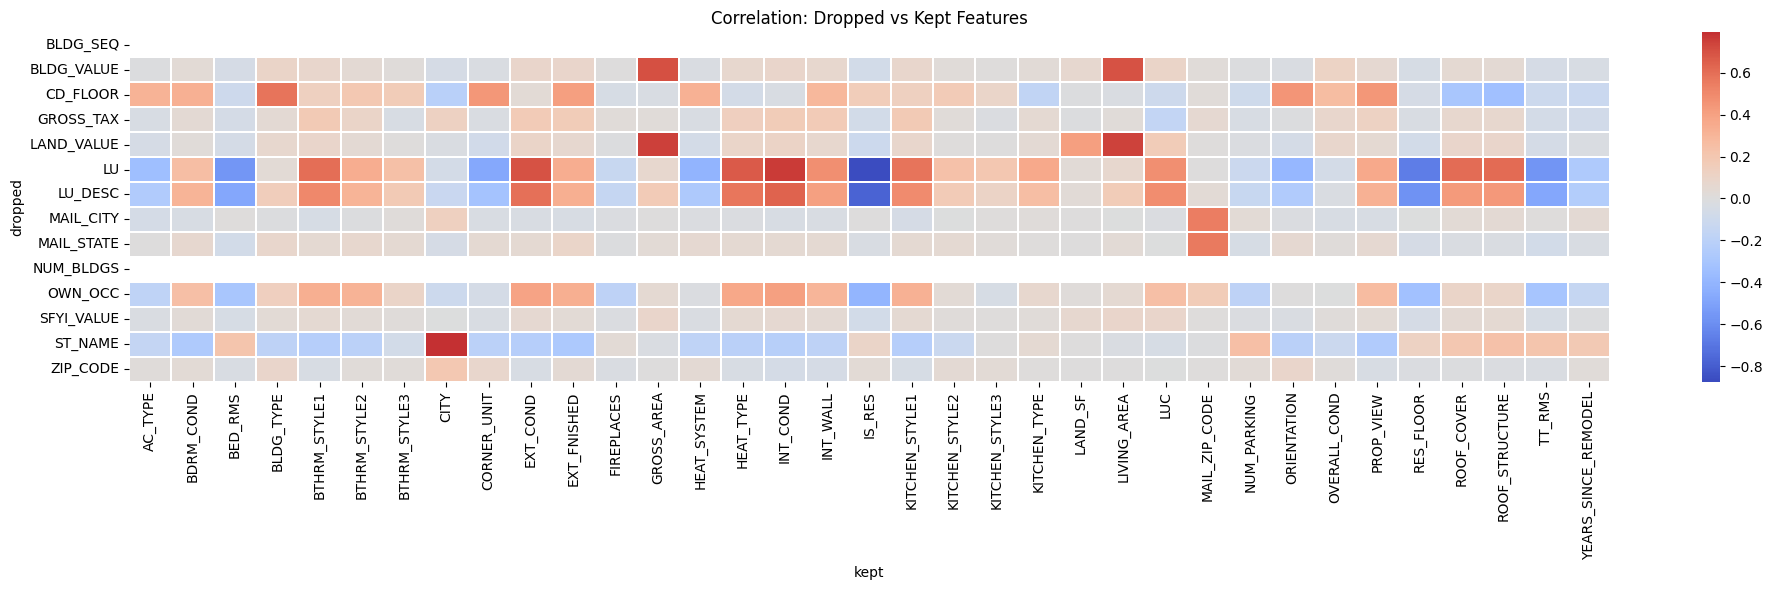

In [196]:
pivot = corr_df.pivot(index='dropped', columns='kept', values='correlation')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 6))
sns.heatmap(pivot, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation: Dropped vs Kept Features')
plt.tight_layout()
plt.show()

## SVD

Lets find the direction of maximum variance in the full feature space.

SVD decomposes X = UΣVᵀ where:
- Σ (singular values) tell us how much variance each direction captures
- Vᵀ (right singular vectors) tell us which features define each direction

We use this to answer:
1. How many independent directions of variation exist in our feature space?
2. What do those directions represent (which features cluster together)?
3. Which original features drive the most variance?

In [197]:
X = df.drop(columns = ['TOTAL_VALUE'])

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_82801/509043193.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_num.select_dtypes(include='object').columns:


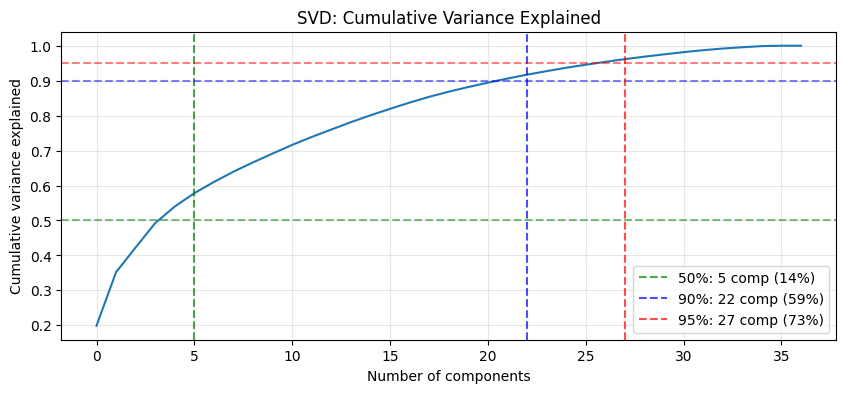

Total features: 37
Threshold      Components      Ratio
------------ ------------ ----------
50%                     5     13.5%
90%                    22     59.5%
95%                    27     73.0%

Top 5 singular values: [1110.85  975.36  662.62  657.41  542.71]

Variance concentration profile:
  PC1 alone:     19.9%
  Top 3 PCs:     42.3%
  Top 10 PCs:    69.1%


In [198]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X_num = X.copy()
for col in X_num.select_dtypes(include='object').columns:
    X_num[col] = LabelEncoder().fit_transform(X_num[col].astype(str))
X_num = X_num.fillna(0).astype(float)

X_scaled = StandardScaler().fit_transform(X_num)

U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
var_explained = (S**2) / (S**2).sum()
cum_var = np.cumsum(var_explained)

# Thresholds
n_50 = (cum_var >= 0.50).argmax() + 1
n_90 = (cum_var >= 0.90).argmax() + 1
n_95 = (cum_var >= 0.95).argmax() + 1
p    = X_scaled.shape[1]

plt.figure(figsize=(10, 4))
plt.plot(cum_var)
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
for threshold, n, color in [(0.50, n_50, 'green'),
                             (0.90, n_90, 'blue'),
                             (0.95, n_95, 'red')]:
    plt.axhline(threshold, color=color, linestyle='--', alpha=0.5)
    plt.axvline(n, color=color, linestyle='--', alpha=0.7,
                label=f'{int(threshold*100)}%: {n} comp ({n/p:.0%})')
plt.legend()
plt.title('SVD: Cumulative Variance Explained')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total features: {p}")
print(f"{'Threshold':12s} {'Components':>12s} {'Ratio':>10s}")
print(f"{'-'*12} {'-'*12} {'-'*10}")
print(f"{'50%':12s} {n_50:>12d} {n_50/p:>9.1%}")
print(f"{'90%':12s} {n_90:>12d} {n_90/p:>9.1%}")
print(f"{'95%':12s} {n_95:>12d} {n_95/p:>9.1%}")
print(f"\nTop 5 singular values: {S[:5].round(2)}")

# Quick read of the profile
print(f"\nVariance concentration profile:")
print(f"  PC1 alone:     {var_explained[0]:.1%}")
print(f"  Top 3 PCs:     {cum_var[2]:.1%}")
print(f"  Top 10 PCs:    {cum_var[min(9, p-1)]:.1%}")

The data has a few strong patterns and a lot of small, independent details. The top 5 components capture 50% of the variance — a clear core signal — but getting to 95% requires 27 of the 37 components, meaning most of the remaining variation is spread thinly and doesn't compress. SVD is not useful for reducing dimensions, but the top components do reveal meaningful structure

In [199]:
print("Component | Var Explained | Cumulative")
for i, (v, c) in enumerate(zip(var_explained[:10], np.cumsum(var_explained[:10]))):
    print(f"   {i+1:2d}     |    {v:.3f}      |   {c:.3f}")

Component | Var Explained | Cumulative
    1     |    0.199      |   0.199
    2     |    0.153      |   0.352
    3     |    0.071      |   0.423
    4     |    0.070      |   0.493
    5     |    0.047      |   0.540
    6     |    0.038      |   0.578
    7     |    0.032      |   0.610
    8     |    0.030      |   0.640
    9     |    0.027      |   0.666
   10     |    0.025      |   0.691


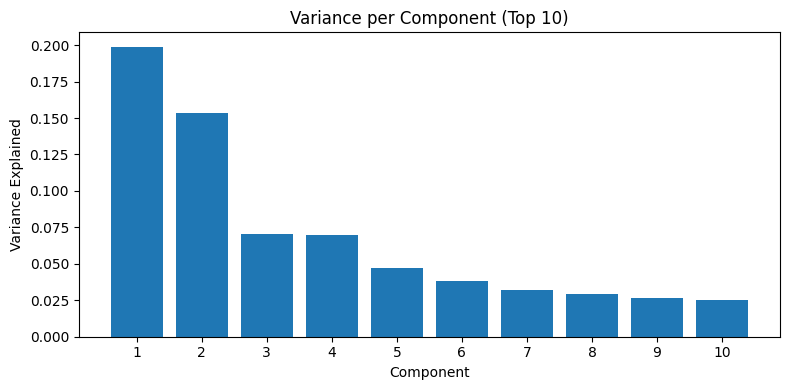

In [200]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), var_explained[:10])
plt.xlabel('Component')
plt.ylabel('Variance Explained')
plt.title('Variance per Component (Top 10)')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

The first component alone explains 22.3% of variance — the largest single axis
of variation in the dataset (residential vs commercial property structure).
Variance drops off steadily: components 1–5 cover 55.9%, components 1–10 cover
70.7%. There is no elbow — no natural cutoff where adding more components stops
being useful. This smooth decay is consistent with genuine multi-dimensional
data where many features carry independent signal

In [201]:
feature_names = X_num.columns.tolist()

print("Top 5 features per component:\n")
for i in range(3):
    top_idx = np.abs(Vt[i]).argsort()[::-1][:5]
    print(f"Principal Component {i+1} (var={var_explained[i]:.3f}):")
    for idx in top_idx:
        print(f"  {feature_names[idx]:25s}  loading={Vt[i][idx]:+.3f}")
    print()

Top 5 features per component:

Principal Component 1 (var=0.199):
  IS_RES                     loading=-0.300
  INT_WALL                   loading=+0.292
  RES_FLOOR                  loading=-0.267
  BED_RMS                    loading=-0.264
  TT_RMS                     loading=-0.263

Principal Component 2 (var=0.153):
  KITCHEN_TYPE               loading=+0.305
  INT_COND                   loading=+0.270
  YEARS_SINCE_REMODEL        loading=-0.268
  EXT_COND                   loading=+0.260
  BTHRM_STYLE1               loading=+0.249

Principal Component 3 (var=0.071):
  EXT_FNISHED                loading=-0.474
  BLDG_TYPE                  loading=-0.396
  LIVING_AREA                loading=+0.366
  GROSS_AREA                 loading=+0.348
  CITY                       loading=-0.216



A feature that loads 0.3 on component 1 (22.3% variance) contributes 0.3² × 0.223 = 0.020 from that component alone, plus whatever it contributes through components 2, 3, ... 37. Lets find the top 10 features accounting for most variance in the feature space

In [202]:
k = 27  # top components (explaining ~70% variance)
feature_var_contrib_topk = (Vt[:k]**2 * var_explained[:k, np.newaxis]).sum(axis=0)

sorted_idx = np.argsort(feature_var_contrib_topk)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_contrib = feature_var_contrib_topk[sorted_idx]

print(f"Top 10 features by contribution to top {k} components:")
for feat, contrib in zip(sorted_features[:37], sorted_contrib[:37]):
    print(f"  {feat:25s}  {contrib:.4f}")

Top 10 features by contribution to top 27 components:
  ST_ZIP                     0.0270
  NUM_PARKING                0.0270
  BDRM_COND                  0.0270
  ORIENTATION                0.0270
  HEAT_TYPE                  0.0270
  OVERALL_COND               0.0269
  FIREPLACES                 0.0269
  PROP_VIEW                  0.0269
  YEARS_SINCE_REMODEL        0.0269
  MAIL_ZIP_CODE              0.0269
  KITCHEN_STYLE2             0.0269
  HEAT_SYSTEM                0.0268
  CORNER_UNIT                0.0268
  ROOF_COVER                 0.0268
  AC_TYPE                    0.0267
  KITCHEN_STYLE3             0.0267
  EXT_COND                   0.0265
  LUC                        0.0263
  GROSS_AREA                 0.0262
  LAND_SF                    0.0261
  BTHRM_STYLE3               0.0261
  LIVING_AREA                0.0261
  RES_FLOOR                  0.0260
  TT_RMS                     0.0259
  BED_RMS                    0.0256
  BTHRM_STYLE2               0.0253
  ROOF_STR

The feature space shows little low-rank structure. ~73% of the features are required to explain 95% variance in feature space, and contributions to the retained subspace (top 27 components) is almost uniform -> Most contributing features (ST_ZIP, NUM_PARKING, YEARS_SINCE_REMODEL, CORNER_UNIT, HEAT_SYSTEM, and HEAT_TYPE) all contribute 0.027 while least contribution (CITY and ROOF_STRUCTURE) also contribute not far from 0.027, at 0.0232

Overall from SVD analysis we find that most features are uncorrelated and for the most part uniformly contributing to the variance in feature space

### Conclusion - SVD/PCA will not yield meaningful compression on this feature set as there are no redundant axes to collapse

## Mutual Information matrix

We have mixed feature types (numeric, ordinal, nominal). Covariance can only properly measure numeric-numeric pairs. MI handles all combinations. That's the primary reason MI was the right tool here

In [203]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# Encode categoricals as integer codes (order doesn't matter for MI)
X_coded = X.copy()
for col in categorical_cols:
    X_coded[col] = X_coded[col].astype('category').cat.codes

# Pairwise MI: for each column, how much does it tell us about every other?
cols = X_coded.columns.tolist()
mi_matrix = pd.DataFrame(0.0, index=cols, columns=cols)

for target in cols:
    is_discrete = [c in categorical_cols for c in cols]
    if target in categorical_cols:
        mi = mutual_info_classif(X_coded, X_coded[target],
                                  discrete_features=is_discrete, random_state=0)
    else:
        mi = mutual_info_regression(X_coded, X_coded[target],
                                     discrete_features=is_discrete, random_state=0)
    mi_matrix[target] = mi

# Symmetrize (MI is symmetric in theory; small numerical differences in practice)
mi_matrix = (mi_matrix + mi_matrix.T) / 2

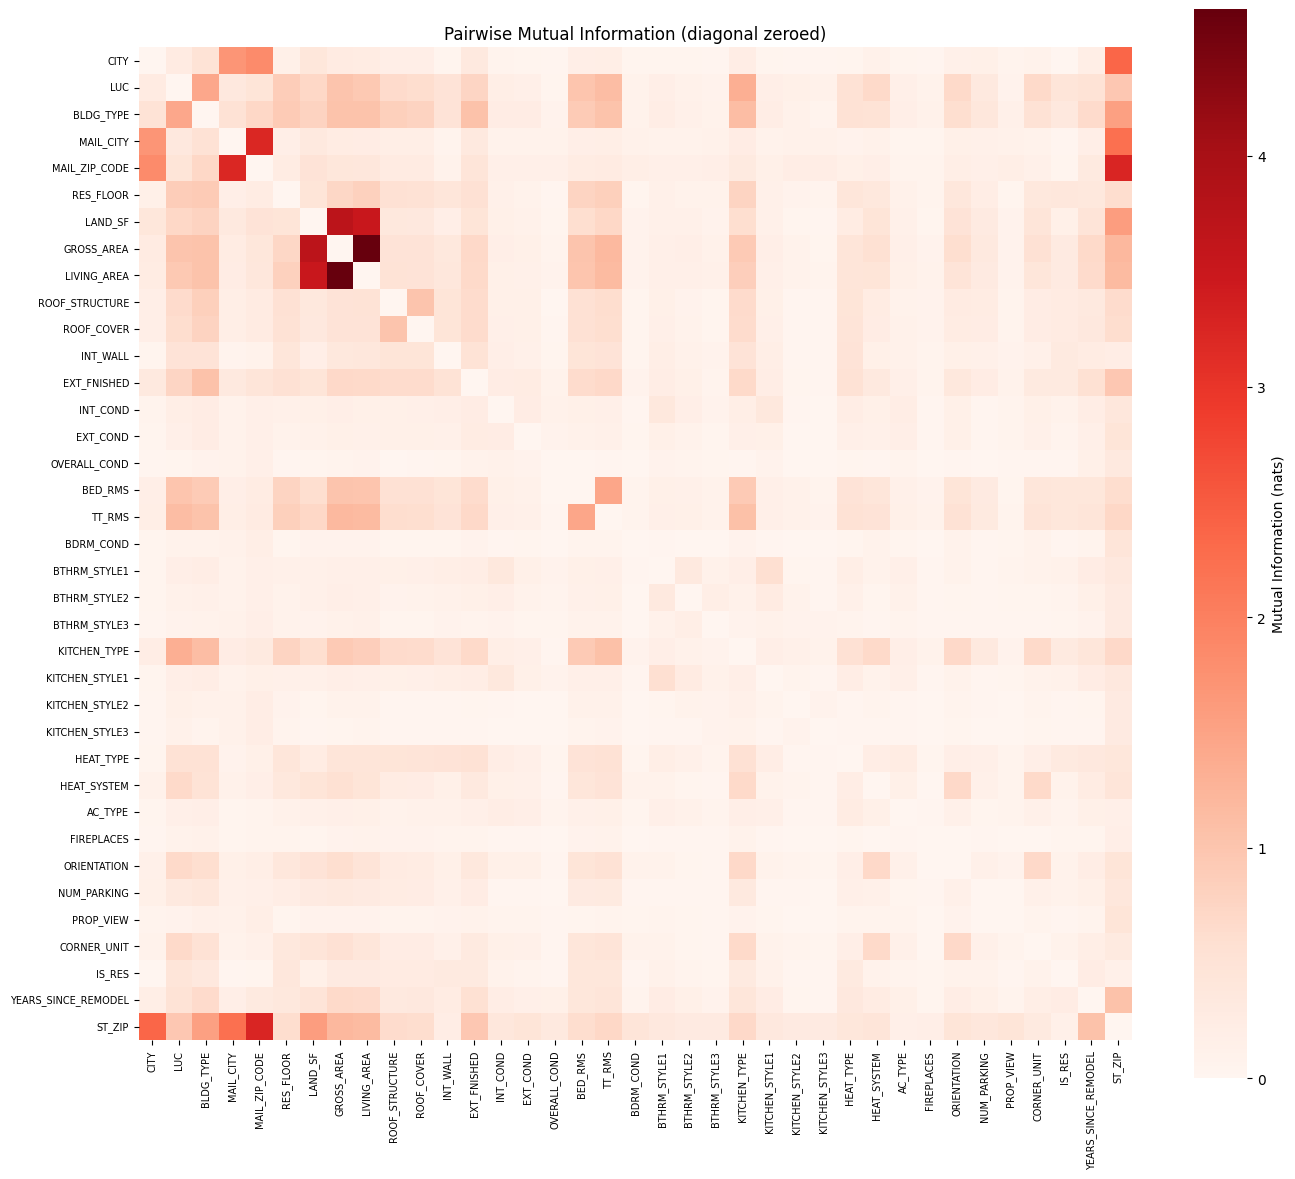

In [204]:
# Build a writable numpy array from the MI matrix
arr = mi_matrix.to_numpy(copy=True).astype(float)
np.fill_diagonal(arr, 0)

# Wrap back into a DataFrame for seaborn
mi_plot = pd.DataFrame(arr, index=mi_matrix.index, columns=mi_matrix.columns)

plt.figure(figsize=(14, 12))
sns.heatmap(mi_plot, cmap='Reds', vmin=0,
            xticklabels=True, yticklabels=True,
            square=True, cbar_kws={'label': 'Mutual Information (nats)'})
plt.title('Pairwise Mutual Information (diagonal zeroed)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

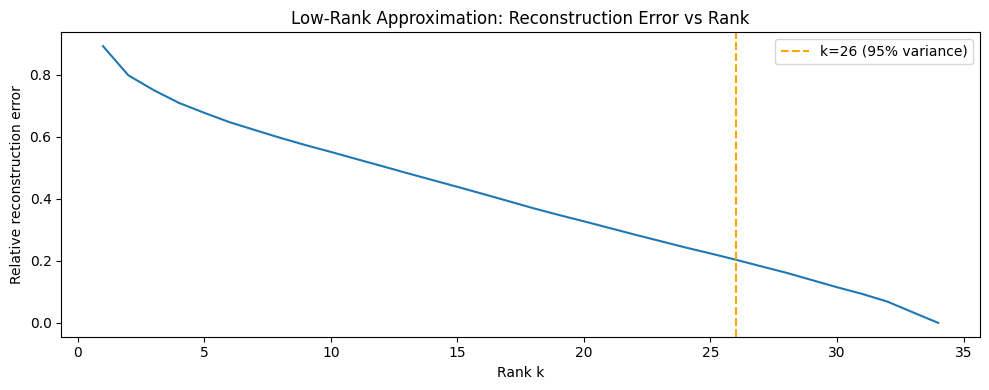

k=1  : 0.8924 error (10.8% captured)
k=5  : 0.6775 error (32.3% captured)
k=10 : 0.5514 error (44.9% captured)
k=26 : 0.2037 error (79.6% captured)


In [208]:
# Low-rank approximation: X̂_k = U_k @ diag(S_k) @ Vt_k
ks = list(range(1, len(S)+1))
errors = []

for k in ks:
    X_approx = U[:, :k] * S[:k] @ Vt[:k, :]
    error = np.linalg.norm(X_scaled - X_approx, 'fro') / np.linalg.norm(X_scaled, 'fro')
    errors.append(error)

plt.figure(figsize=(10, 4))
plt.plot(ks, errors)
plt.axvline(n_95, color='orange', linestyle='--', label=f'k={n_95} (95% variance)')
plt.xlabel('Rank k')
plt.ylabel('Relative reconstruction error')
plt.title('Low-Rank Approximation: Reconstruction Error vs Rank')
plt.legend()
plt.tight_layout()
plt.show()

print(f"k=1  : {errors[0]:.4f} error ({(1-errors[0])*100:.1f}% captured)")
print(f"k=5  : {errors[4]:.4f} error ({(1-errors[4])*100:.1f}% captured)")
print(f"k=10 : {errors[9]:.4f} error ({(1-errors[9])*100:.1f}% captured)")
print(f"k={n_95} : {errors[n_95-1]:.4f} error ({(1-errors[n_95-1])*100:.1f}% captured)")

In [209]:
print("k  | Var Explained | Frob Captured")
for k in [1, 5, 10, 26, 27]:
    var_exp = np.cumsum(var_explained)[k-1]
    frob_cap = 1 - errors[k-1]
    print(f"{k:2d} |     {var_exp:.3f}     |    {frob_cap:.3f}")

k  | Var Explained | Frob Captured
 1 |     0.204     |    0.108
 5 |     0.541     |    0.323
10 |     0.696     |    0.449
26 |     0.959     |    0.796
27 |     0.967     |    0.817


Weak/no low-rank structure; every component contributes roughly equally. Re-affirms SVD analysis

## Outlier detection

Threshold (99.9%): 8.08
Outliers detected: 10716 (6.39%)


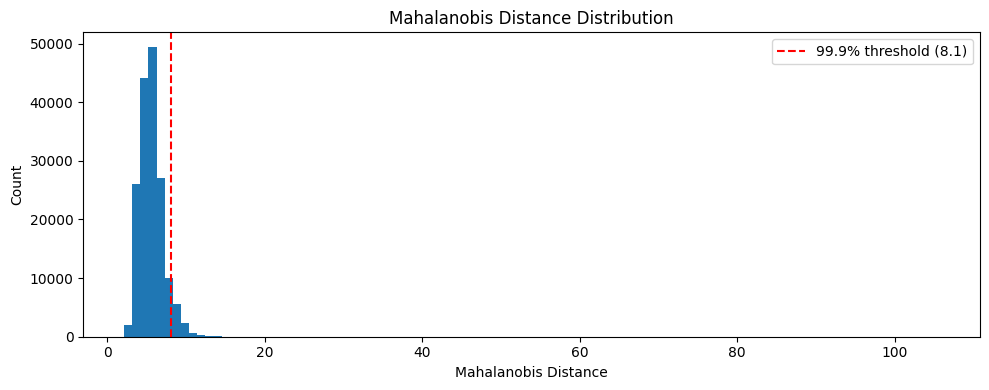

In [211]:
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

# Use X_num (unscaled numeric) for covariance
mean = X_num.mean(axis=0)
C = np.cov(X_num.T)
C_inv = np.linalg.pinv(C)  # pseudo-inverse handles near-singular matrix

# Compute Mahalanobis distance for each row
X_centered = X_num - mean
mahal_dist = np.sqrt(np.einsum('ij,jk,ik->i', X_centered, C_inv, X_centered))

# Chi-squared threshold: squared Mahalanobis ~ chi2(p) under normality
p = X_num.shape[1]
threshold = np.sqrt(chi2.ppf(0.999, df=p))
outliers = mahal_dist > threshold

print(f"Threshold (99.9%): {threshold:.2f}")
print(f"Outliers detected: {outliers.sum()} ({outliers.mean()*100:.2f}%)")

plt.figure(figsize=(10, 4))
plt.hist(mahal_dist, bins=100, edgecolor='none')
plt.axvline(threshold, color='r', linestyle='--', label=f'99.9% threshold ({threshold:.1f})')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Count')
plt.title('Mahalanobis Distance Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [217]:
outlier_df = df.iloc[outliers]
normal_df = df.iloc[~outliers]

print("Outliers vs Normal properties:\n")
for col in ['TOTAL_VALUE', 'GROSS_AREA']:
    print(f"{col:20s}  outlier_median={outlier_df[col].median():>12.1f}  normal_median={normal_df[col].median():>12.1f}")

print(f"\nOutlier IS_RES breakdown:")
print(outlier_df['IS_RES'].value_counts())

Outliers vs Normal properties:

TOTAL_VALUE           outlier_median=   1689450.0  normal_median=    687100.0
GROSS_AREA            outlier_median=         7.9  normal_median=         7.3

Outlier IS_RES breakdown:
IS_RES
1    10008
0      708
Name: count, dtype: int64


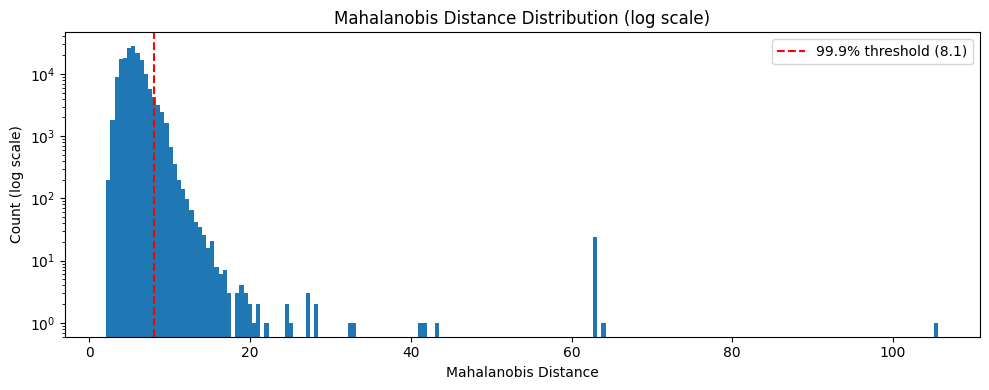

Max distance: 105.7
99th percentile: 9.9
99.9th percentile: 13.6


In [218]:
plt.figure(figsize=(10, 4))
plt.hist(mahal_dist, bins=200, edgecolor='none')
plt.axvline(threshold, color='r', linestyle='--', label=f'99.9% threshold ({threshold:.1f})')
plt.yscale('log')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Count (log scale)')
plt.title('Mahalanobis Distance Distribution (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Max distance: {mahal_dist.max():.1f}")
print(f"99th percentile: {np.percentile(mahal_dist, 99):.1f}")
print(f"99.9th percentile: {np.percentile(mahal_dist, 99.9):.1f}")

In [220]:
spike_mask = (mahal_dist > 60) & (mahal_dist < 70)
print(f"Properties in spike: {spike_mask.sum()}")
print(df.iloc[spike_mask][['TOTAL_VALUE', 'IS_RES', 'LUC', 'BLDG_TYPE', 'GROSS_AREA']].to_string())

Properties in spike: 25
       TOTAL_VALUE  IS_RES  LUC              BLDG_TYPE  GROSS_AREA
7455         70000       0  108          LR - Low Rise    0.000000
7456         70000       0  108          LR - Low Rise    0.000000
7457         70000       0  108          LR - Low Rise    0.000000
7458         70000       0  108          LR - Low Rise    0.000000
7459         70000       0  108          LR - Low Rise    0.000000
7460         70000       0  108          LR - Low Rise    0.000000
7461         70000       0  108          LR - Low Rise    0.000000
7462         70000       0  108          LR - Low Rise    0.000000
7463         70000       0  108          LR - Low Rise    0.000000
7464         70000       0  108          LR - Low Rise    0.000000
7465         70000       0  108          LR - Low Rise    0.000000
7466         70000       0  108          LR - Low Rise    0.000000
7467         70000       0  108          LR - Low Rise    0.000000
7468         70000       0  108       

In [222]:
extreme_idx = mahal_dist.argmax()
print(df.iloc[extreme_idx][['TOTAL_VALUE', 'IS_RES', 'LUC', 'BLDG_TYPE', 'GROSS_AREA']])

TOTAL_VALUE                 137407100
IS_RES                              0
LUC                               357
BLDG_TYPE      320 - RET/WHSL/SERVICE
GROSS_AREA                  12.550375
Name: 35546, dtype: object


Outliers -

- Rows 7455-7478: data quality — duplicate parking/storage records with zero area
- Row 20711: legitimate extreme — largest residential building ($189M, 362k sqft)
- Row 35546: legitimate extreme — largest commercial property ($137M, 283k sqft)

### Duplicate parking lots

In [223]:
print(df.iloc[7455:7479].to_string())

             CITY  LUC      BLDG_TYPE MAIL_ZIP_CODE  RES_FLOOR  GROSS_AREA  TOTAL_VALUE ROOF_STRUCTURE       ROOF_COVER            INT_WALL        EXT_FNISHED  INT_COND  EXT_COND  OVERALL_COND  BDRM_COND  BTHRM_STYLE1  BTHRM_STYLE2  BTHRM_STYLE3 KITCHEN_TYPE  KITCHEN_STYLE1  KITCHEN_STYLE2  KITCHEN_STYLE3 HEAT_TYPE        HEAT_SYSTEM   AC_TYPE  FIREPLACES        ORIENTATION  NUM_PARKING  PROP_VIEW        CORNER_UNIT  IS_RES  YEARS_SINCE_REMODEL         ST_ZIP
7455  EAST BOSTON  108  LR - Low Rise         02128       -1.0         0.0        70000       F - Flat  R - Rubber Roof  NA - Not Available  V - Brck/Stn Venr         2         4             4          2             1             1             1     N - None               1               1               1  N - None  NR - Not Required  N - None         0.0  NR - Not Required        125.0          2  NR - Not Required       0                  9.0  LEWIS ST_2128
7456  EAST BOSTON  108  LR - Low Rise         02128       -1.0         0

The different MAIL_ZIP_CODE proves that these are 24 different parking lots located in the same area they are owned by different people. These are not data entry errors and should be kept